In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU devices
os.environ["TFDS_DATA_DIR"] = os.path.expanduser("~/tensorflow_datasets")  # default location of tfds database
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import tensorflow as tf
import tensorflow_datasets as tfds
import librosa.display

import matplotlib.pyplot as plt

# Turn off logging for TF
import logging
tf.get_logger().setLevel(logging.ERROR)

from dpmhm.datasets import feature, transformer, _DTYPE, _ENCLEN

from IPython.display import Audio

ds_all, ds_info = tfds.load(
    'CWRU',
    with_info=True,
)

ds0 = ds_all['train']
ds0.element_spec

2024-06-13 13:26:10.707242: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-13 13:26:10.711757: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-13 13:26:10.773614: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-13 13:26:12.114557: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-06-13 13:26:14.893163: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2024-06-13 13:26:14.893193: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] ret

{'metadata': {'Dataset': TensorSpec(shape=(), dtype=tf.string, name=None),
  'FaultComponent': TensorSpec(shape=(), dtype=tf.string, name=None),
  'FaultLocation': TensorSpec(shape=(), dtype=tf.string, name=None),
  'FaultSize': TensorSpec(shape=(), dtype=tf.float32, name=None),
  'FileName': TensorSpec(shape=(), dtype=tf.string, name=None),
  'LoadForce': TensorSpec(shape=(), dtype=tf.uint32, name=None),
  'NominalRPM': TensorSpec(shape=(), dtype=tf.uint32, name=None),
  'RPM': TensorSpec(shape=(), dtype=tf.uint32, name=None)},
 'sampling_rate': TensorSpec(shape=(), dtype=tf.uint32, name=None),
 'signal': {'BA': TensorSpec(shape=(None,), dtype=tf.float32, name=None),
  'DE': TensorSpec(shape=(None,), dtype=tf.float32, name=None),
  'FE': TensorSpec(shape=(None,), dtype=tf.float32, name=None)}}

In [3]:
compactor = transformer.DatasetCompactor(ds0,
                                         channels=['DE', 'FE', 'BA'],
                                         keys=['FaultLocation', 'FaultComponent', 'FaultSize'],
                                         resampling_rate=12000,window_size = int(12000), hop_size=int(12000/2))

compactor.dataset.element_spec

2024-06-13 13:26:18.046478: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


{'label': TensorSpec(shape=(), dtype=tf.string, name=None),
 'sampling_rate': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'signal': TensorSpec(shape=(3, None), dtype=tf.float32, name=None)}

(12000,)


2024-06-13 13:26:18.534418: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


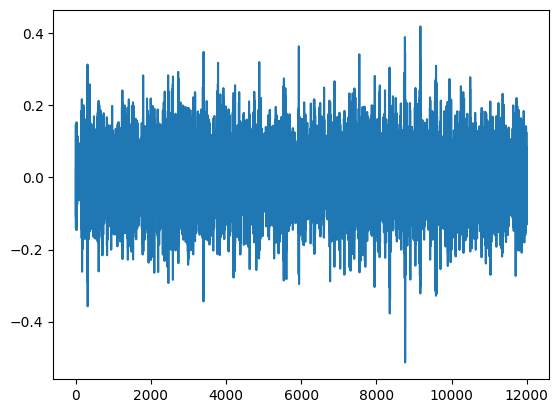

In [4]:
import numpy as np

eles1 = list(compactor.dataset.take(10).as_numpy_iterator())
x0= eles1[0]['signal'][0]
print(x0.shape)

plt.plot(np.arange(len(x0)), x0)
Audio(x0, rate=12000)

(3, 64, 64)


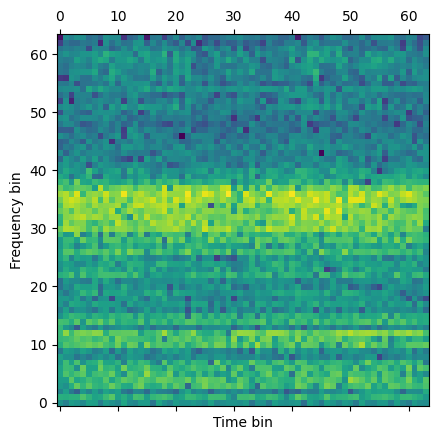

In [5]:
def spectrogram(signal, sampling_rate, extractor: callable) -> dict:
    """Feature transform of a signal element.

    The transformed element has a dictionary structure which contains
    """
    Xf = tf.py_function(
        func=lambda x, sr: extractor(x.numpy(), sr),  
        inp=[signal, sampling_rate],
        Tout=_DTYPE
    )
    # Xf.set_shape((signal.shape[0], None, None))
    Xf = tf.expand_dims(Xf, axis=-1)  # Add a channel dimension
    Xf = tf.image.resize(Xf, (64, 64), method=tf.image.ResizeMethod.BICUBIC)
    Xf = tf.squeeze(Xf, axis=-1)  # Remove the channel dimension
    return Xf

_func = lambda x, sr: feature.spectral_features(x, sr, 'spectrogram', 
                                                time_window=0.025, hop_step=0.0125, normalize=False,
                                                to_db=True)[0]

img=spectrogram(eles1[0]['signal'],eles1[0]['sampling_rate'], _func)
plt.matshow(img[0], origin='lower')
plt.xlabel('Time bin')
plt.ylabel('Frequency bin')

print(img.shape)

2024-06-13 13:26:19.715985: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


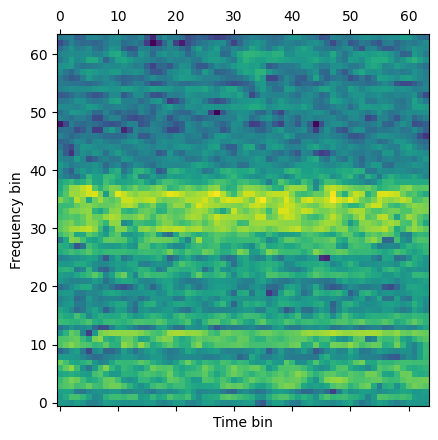

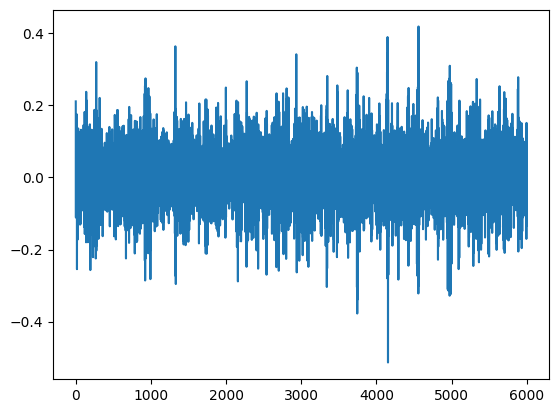

In [6]:
seg_length = 6000
nb_elements=3

def create_pairs(element, seg_length, nb_elements):
    signal = element['signal']
    label = element['label']
    sampling_rate = element['sampling_rate']

    pairs = []

    for _ in range(nb_elements):
        start_idx_1 = tf.random.uniform(shape=(), minval=0, maxval=signal.shape[1] - seg_length, dtype=tf.int32)
        start_idx_2 = tf.random.uniform(shape=(), minval=0, maxval=signal.shape[1] - seg_length, dtype=tf.int32)

        # Extraire des segments de chaque canal
        sig1 = signal[:, start_idx_1:start_idx_1 + seg_length]
        sig2 = signal[:, start_idx_2:start_idx_2 + seg_length]

        # Calculer les caractéristiques spectrogramme pour le deuxième signal
        sig2_features = spectrogram(sig2, sampling_rate, _func)

        pairs.append(((sig1, label), (sig2_features, label)))

    return pairs

def flatten_pairs(element, seg_length, nb_elements):
    pairs = create_pairs(element, seg_length, nb_elements)
    sig1_list = []
    sig2_features_list = []
    label_list = []

    for pair in pairs:
        sig1_list.append(pair[0][0])
        sig2_features_list.append(pair[1][0])
        label_list.append(pair[0][1])
    
    return (sig1_list, sig2_features_list, label_list)

def generator(seg_length, nb_elements):
    for element in compactor.dataset:
        sig1_list, sig2_features_list, label_list = flatten_pairs(element, seg_length, nb_elements)
        for sig1, sig2_features, label in zip(sig1_list, sig2_features_list, label_list):
            yield (sig1, label), (sig2_features, label)

new_dataset = tf.data.Dataset.from_generator(lambda: generator(seg_length, nb_elements), output_signature=(
    ((tf.TensorSpec(shape=(3, seg_length), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.string)),
    (tf.TensorSpec(shape=(3,None, None), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.string)))))
new_dataset.element_spec

for element in new_dataset.take(1):
    first_element = element

plt.matshow(first_element[1][0][0], origin='lower')
plt.xlabel('Time bin')
plt.ylabel('Frequency bin')

plt.figure()
plt.plot(np.arange(len(first_element[0][0][0])), first_element[0][0][0])

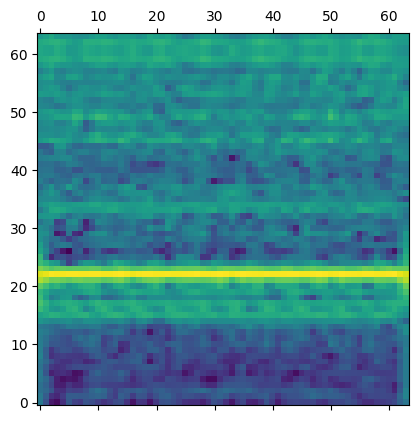

In [7]:
contrastive_augmenter = keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomZoom(0.2),
            layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
        ], name='Data_augmentation')

aug_elem=contrastive_augmenter(first_element[1][0])

plt.matshow(aug_elem[0], origin='lower')

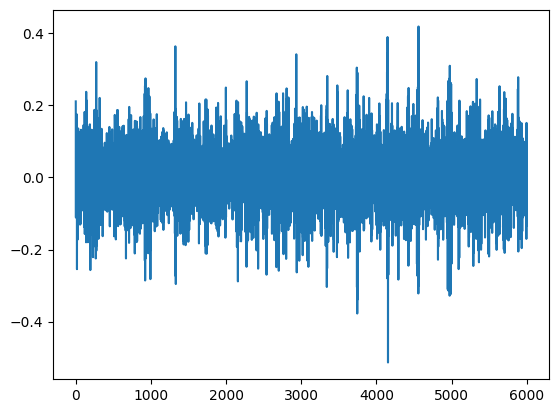

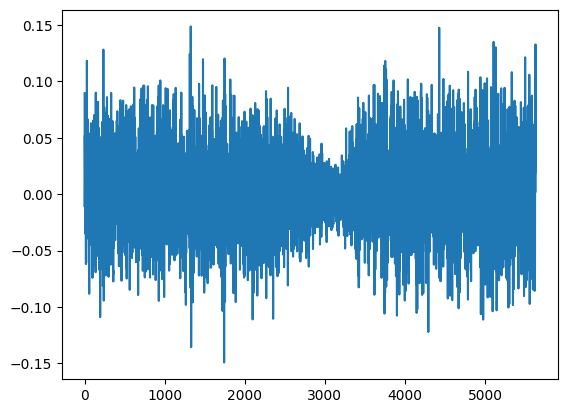

In [58]:
plt.plot(first_element[0][0][0])

def mix_audio(x1, x2, alpha):
    return alpha * x1 + (1 - alpha) * x2

def time_mask(audio, t):
    t0 = tf.random.uniform(shape=[], minval=0, maxval=len(audio) - t, dtype=tf.int32)
    mask = tf.ones_like(audio)
    mask = tf.tensor_scatter_nd_update(mask, tf.range(t0, t0 + t)[:, None], tf.zeros((t,), dtype=audio.dtype))
    audio = audio * mask
    return audio

def freq_mask(spectrogram, f):
    f0 = np.random.randint(0, spectrogram.shape[1] - f)
    spectrogram[:, f0:f0+f] = 0
    return spectrogram

def frequency_shift(spectrogram, shift_freq, fs):
    freq_bins, _ = spectrogram.shape
    X = np.fft.fft(spectrogram, axis=0)
    phase_shift = np.exp(1j * 2 * np.pi * shift_freq * np.arange(freq_bins) / fs)
    X_shifted = X * phase_shift[:, np.newaxis]
    shifted_spectrogram = np.fft.ifft(X_shifted, axis=0)

    return np.real(shifted_spectrogram)

noise_amplitude = 0.1
noise = tf.random.normal(first_element[0][0][0].shape, mean=0.0, stddev=noise_amplitude, dtype=tf.float32)

alpha = np.random.beta(5, 2)
mixed_audio = mix_audio(first_element[0][0][0], noise, alpha)

t = np.random.randint(len(first_element[0][0][0])/50, len(first_element[0][0][0])/20) 
mixed_audio = time_mask(mixed_audio, t)

spectrogram = librosa.stft(mixed_audio.numpy())
f = np.random.randint(1, spectrogram.shape[1] // 4)
spectrogram = freq_mask(spectrogram, f)

spectrogram = frequency_shift(spectrogram, 2, 12000)

reconstructed_audio = librosa.istft(spectrogram)
plt.figure()
plt.plot(np.arange(len(reconstructed_audio)), reconstructed_audio)

Audio(first_element[0][0][0], rate=12000)
Audio(reconstructed_audio, rate=12000)